# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [42]:
# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [43]:
nutri = pd.read_csv('data/nndb_flat.csv')

In [44]:
nutri.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [45]:
nutri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [46]:
nutri.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,8618.0,15467.757368,9221.428766,1001.0,8695.250000,14273.000000,20050.750000,93600.000000
Energy_kcal,8618.0,226.438617,169.388910,0.0,93.000000,191.000000,336.000000,902.000000
Protein_g,8618.0,11.523910,10.550590,0.0,2.470000,8.285000,19.977500,88.320000
Fat_g,8618.0,10.647024,15.866353,0.0,0.992500,5.235000,13.900000,100.000000
Carb_g,8618.0,21.819062,27.239000,0.0,0.040000,8.945000,32.900000,100.000000
Sugar_g,8618.0,6.560253,13.602098,0.0,0.000000,0.370000,5.300000,99.800000
Fiber_g,8618.0,2.023242,4.313670,0.0,0.000000,0.300000,2.400000,79.000000
VitA_mcg,8618.0,93.968786,779.362205,0.0,0.000000,1.500000,21.000000,30000.000000
VitB6_mg,8618.0,0.264369,0.478614,0.0,0.034250,0.120000,0.355000,12.000000
VitB12_mcg,8618.0,1.225260,4.319183,0.0,0.000000,0.080000,1.297500,98.890000


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

Las quito porque no sirven para nada, se trata de *Recommended Dietary Allowances*.

In [ ]:
# Seleccionamos las columnas USRDA
data = nutri.drop(columns=nutri.filter(regex='_USRDA$').columns, axis=1)

### Variables no numéricas
Elimina las variables de texto del dataset

In [ ]:
data = data.select_dtypes(include=['number']).drop(columns='ID',axis=1)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Energy_kcal    8618 non-null   float64
 1   Protein_g      8618 non-null   float64
 2   Fat_g          8618 non-null   float64
 3   Carb_g         8618 non-null   float64
 4   Sugar_g        8618 non-null   float64
 5   Fiber_g        8618 non-null   float64
 6   VitA_mcg       8618 non-null   float64
 7   VitB6_mg       8618 non-null   float64
 8   VitB12_mcg     8618 non-null   float64
 9   VitC_mg        8618 non-null   float64
 10  VitE_mg        8618 non-null   float64
 11  Folate_mcg     8618 non-null   float64
 12  Niacin_mg      8618 non-null   float64
 13  Riboflavin_mg  8618 non-null   float64
 14  Thiamin_mg     8618 non-null   float64
 15  Calcium_mg     8618 non-null   float64
 16  Copper_mcg     8618 non-null   float64
 17  Iron_mg        8618 non-null   float64
 18  Magnesiu

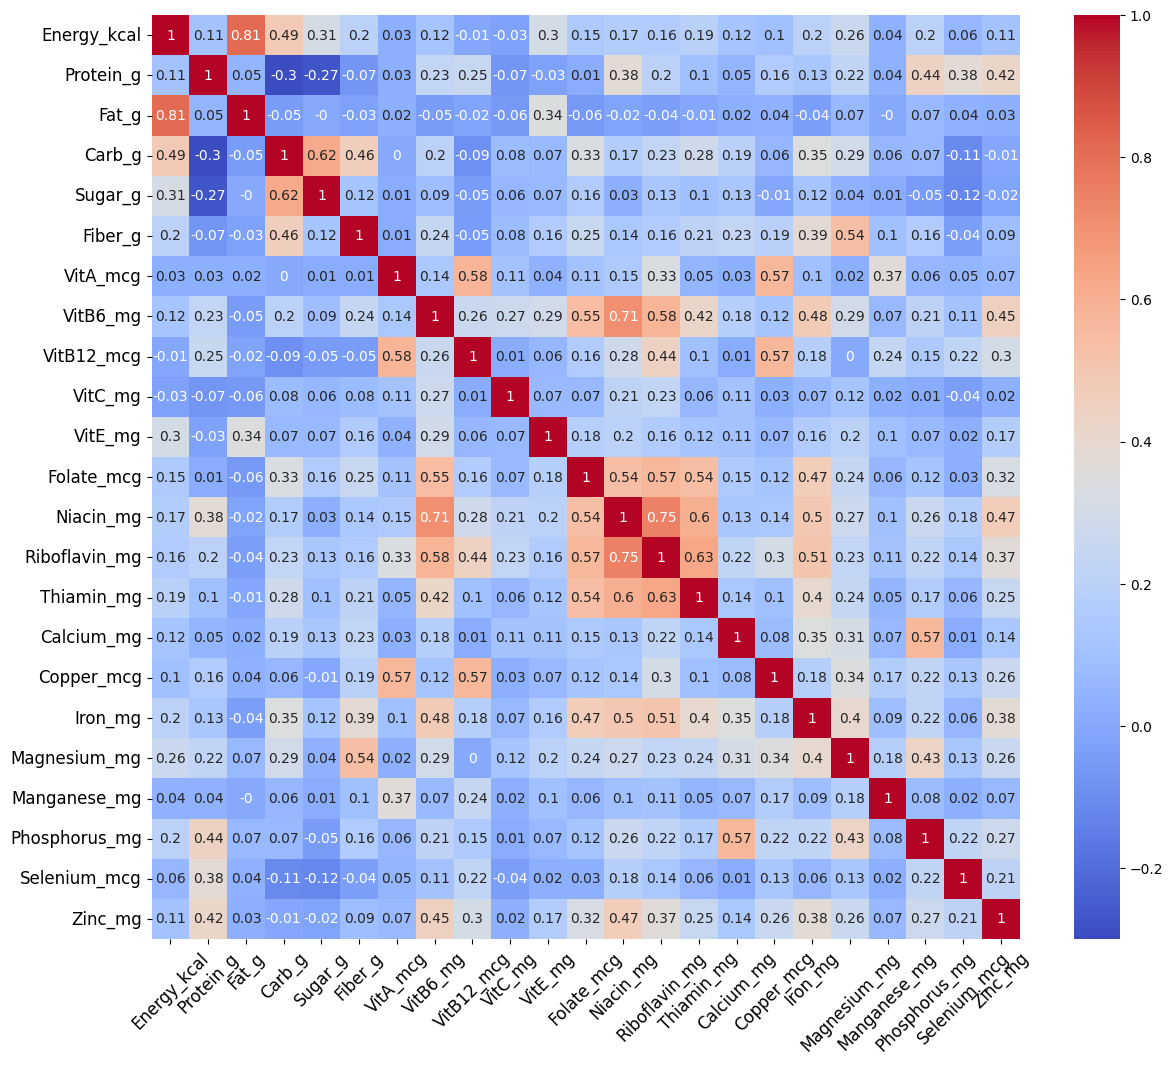

In [11]:
plt.figure(figsize=(14, 12))
sns.heatmap(round(data.corr(),2), annot=True, cmap='coolwarm')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12);

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

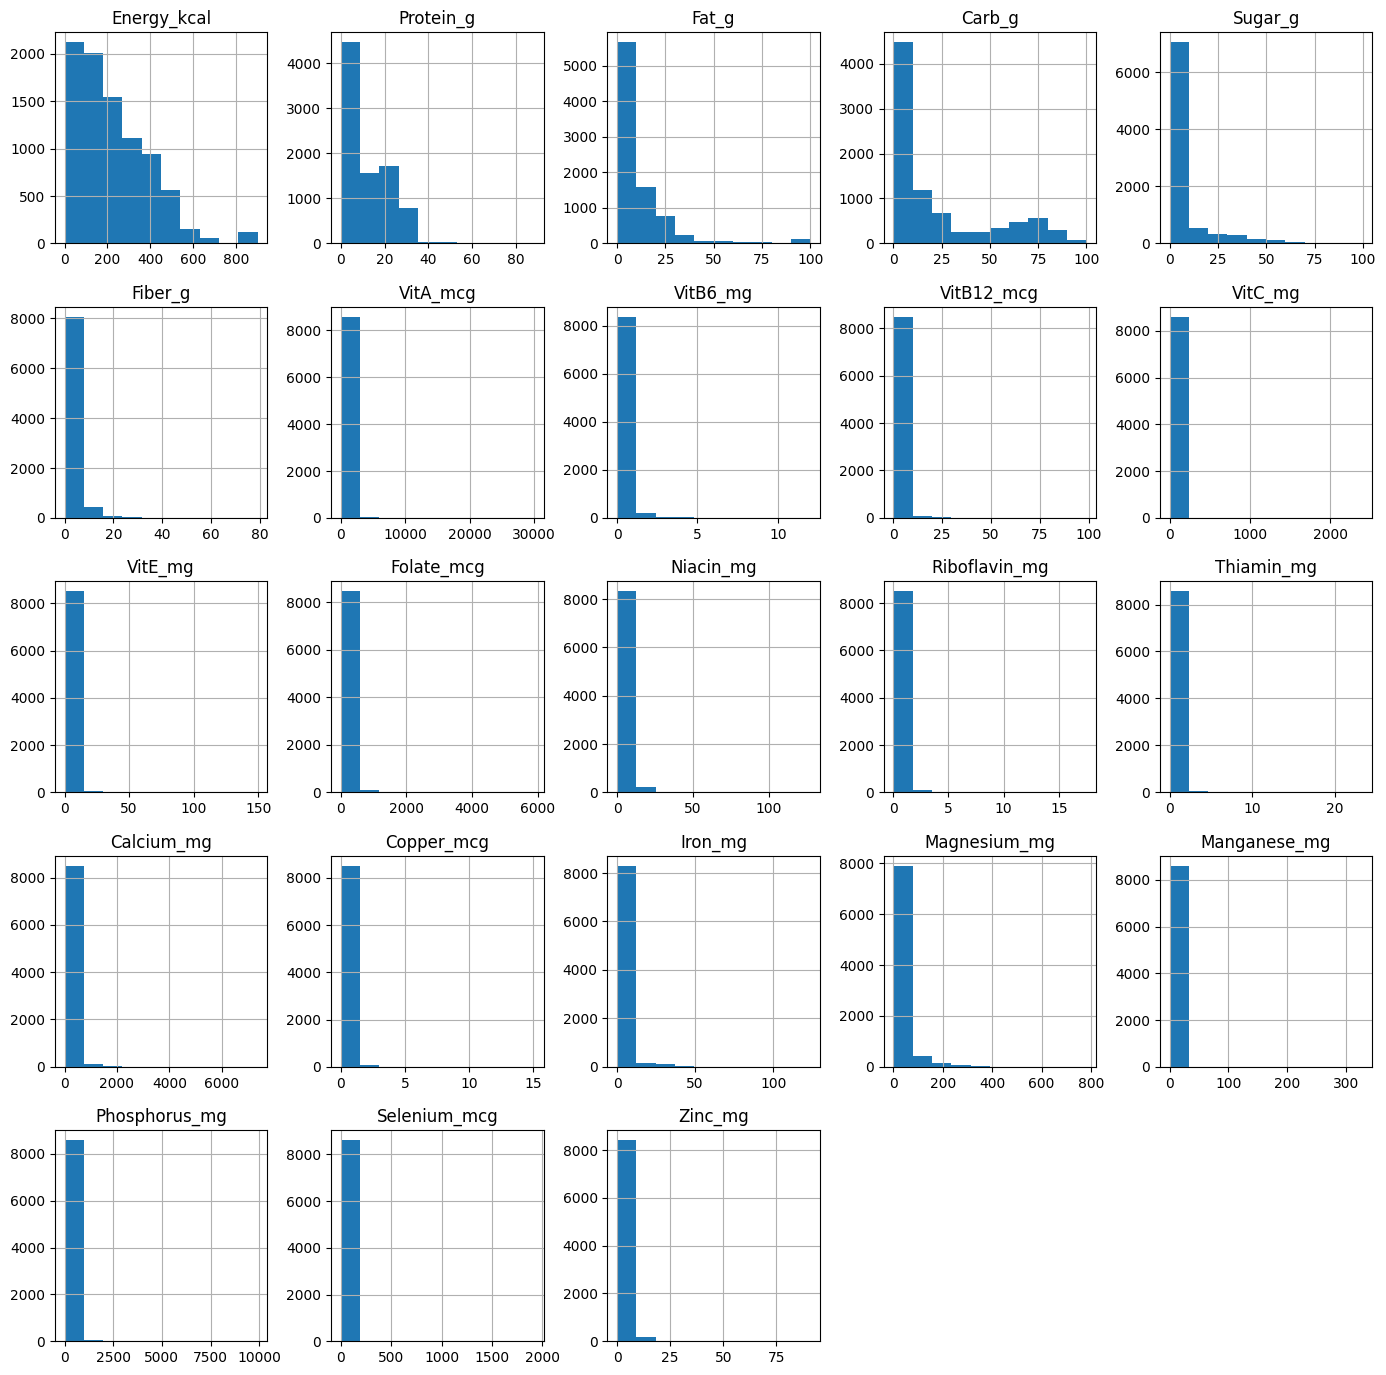

In [16]:
data.hist(figsize=(17,17));

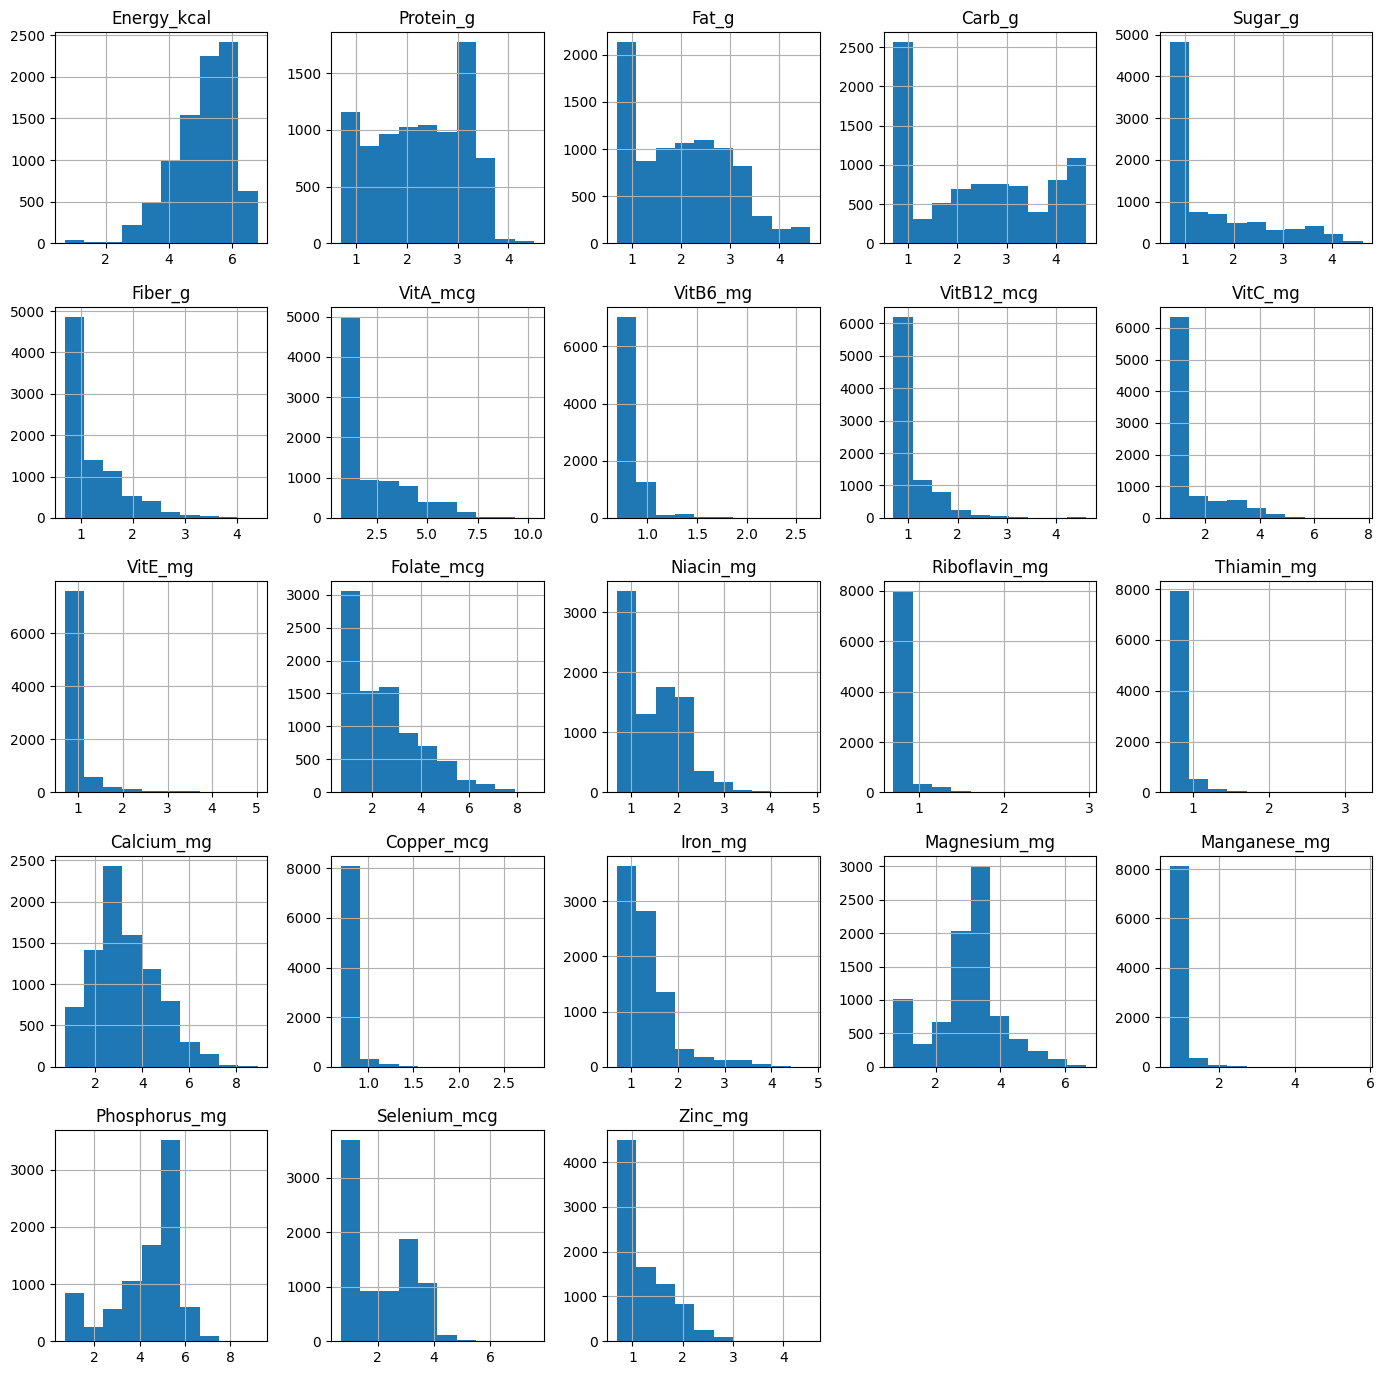

In [22]:
# Los pasamos a logaritmo y volvemos a visualizar
data_log = data.apply(lambda x: np.log1p(x - x.min() + 1))

data_log.hist(figsize=(17,17));

No parece solucionar mucho..

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [ ]:
from sklearn.preprocessing import StandardScaler

X = data_log

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [32]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_std)

df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
0,-2.065034,-0.732158,1.598623,-1.011300,3.938018,-0.127474,0.010443,-1.816838,-0.459521,0.378015,...,0.007057,0.565411,-0.351086,0.346278,0.075936,-0.153047,-0.256187,-0.036794,0.143536,-0.920103
1,-2.045300,-0.690609,1.606723,-1.006544,3.918870,-0.161215,0.048054,-1.845612,-0.479665,0.403567,...,0.057293,0.548791,-0.284129,0.290274,0.057418,-0.149445,-0.293527,-0.080150,0.134073,-0.923600
2,-2.988656,-0.835203,1.889836,-1.958197,3.954382,-1.072683,0.162430,-2.052381,-0.378567,0.410650,...,0.102767,0.624344,0.034882,0.410506,0.166780,-0.315377,-0.109606,0.090792,-0.117879,-0.854716
3,1.419413,-1.252804,0.316205,0.958086,2.484027,2.161636,0.323525,-0.697357,-0.533322,0.134704,...,-0.421456,0.703221,-0.594284,0.220526,0.588569,-0.059298,0.443933,-0.117288,0.023991,-0.044223
4,1.195213,-1.217412,0.490770,1.156609,2.737438,2.374921,0.563073,-0.667273,-0.838296,0.076835,...,-0.303474,0.432541,-0.583551,0.479096,0.505169,-0.271759,0.540777,-0.348767,-0.024654,0.017856


### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

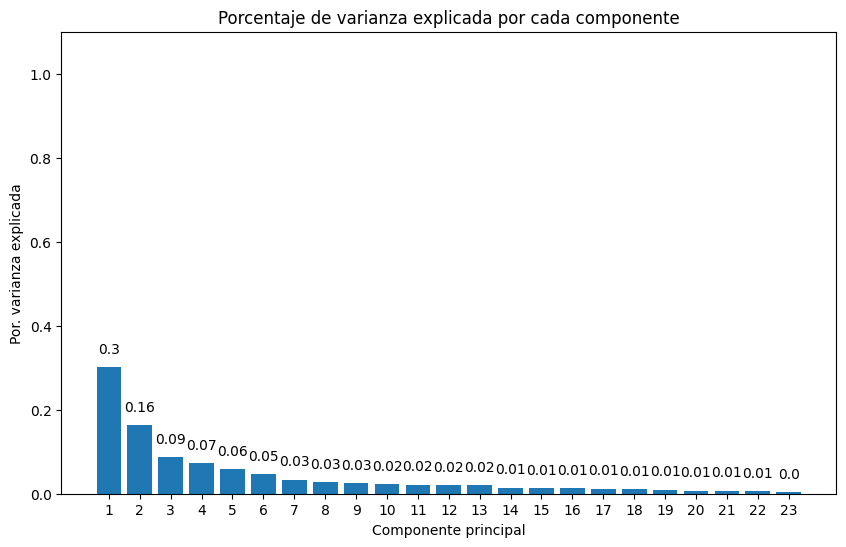

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.bar(
    x      = np.arange(pca.n_components_) + 1,
    height = pca.explained_variance_ratio_
)

for x, y in zip(np.arange(len(df_pca.columns)) + 1, pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

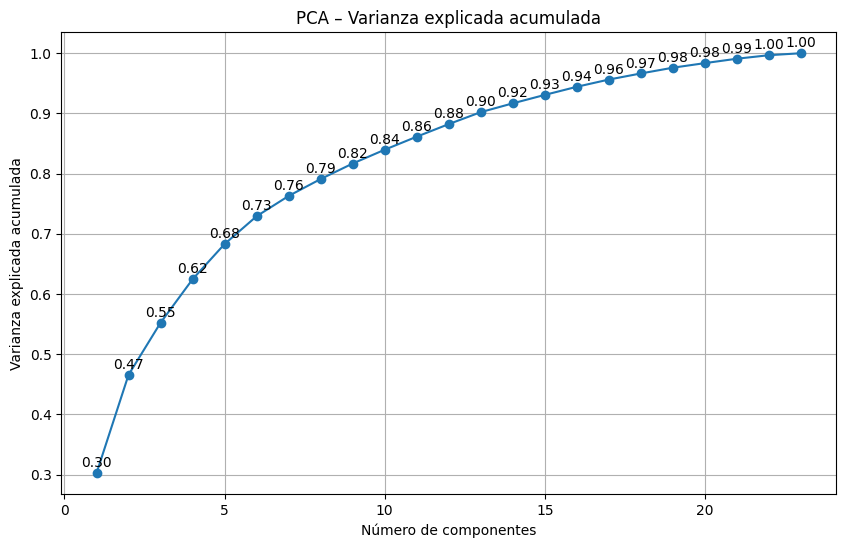

In [37]:
# Varianza explicada acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')

# Añadir etiquetas encima de cada punto
for i, v in enumerate(var_acum):
    plt.text(i + 1, v + 0.01, f"{v:.2f}", ha='center')

plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA – Varianza explicada acumulada')
plt.grid(True)
plt.show();


El sexto punto nos da el 73% de la varianza original. Nos quedamos con los primeros 6 features.

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [40]:
from sklearn.decomposition import PCA

pca6 = PCA(n_components=6)
X_pca6 = pca6.fit_transform(X_std)

df_pca6 = pd.DataFrame(
    X_pca6,
    columns=[f'PC{i+1}' for i in range(6)]
)

df_pca6.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.065034,-0.732158,1.598623,-1.011300,3.938018,-0.127474
1,-2.045300,-0.690609,1.606723,-1.006544,3.918870,-0.161215
2,-2.988656,-0.835203,1.889836,-1.958197,3.954382,-1.072683
3,1.419413,-1.252804,0.316205,0.958086,2.484027,2.161636
4,1.195213,-1.217412,0.490770,1.156609,2.737438,2.374921


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [48]:
df_pc_food = pd.concat([nutri['FoodGroup'], df_pca6], axis=1)

In [49]:
top_foodgroups = {}

for pc in df_pca6.columns:
    top_foodgroups[pc] = (
        df_pc_food.groupby('FoodGroup')[pc]
        .mean()
        .sort_values(ascending=False)
        .head(3)
    )

In [50]:
for pc, series in top_foodgroups.items():
    print(f"\nTop 3 FoodGroups para {pc}:")
    print(series)


Top 3 FoodGroups para PC1:
FoodGroup
Breakfast Cereals        4.325773
Nut and Seed Products    3.165472
Spices and Herbs         2.845744
Name: PC1, dtype: float64

Top 3 FoodGroups para PC2:
FoodGroup
Spices and Herbs         3.621536
Breakfast Cereals        2.784637
Nut and Seed Products    1.908135
Name: PC2, dtype: float64

Top 3 FoodGroups para PC3:
FoodGroup
Fats and Oils            2.157506
Nut and Seed Products    1.698775
Baked Products           1.604873
Name: PC3, dtype: float64

Top 3 FoodGroups para PC4:
FoodGroup
Spices and Herbs           1.880598
Nut and Seed Products      1.823318
Cereal Grains and Pasta    1.257530
Name: PC4, dtype: float64

Top 3 FoodGroups para PC5:
FoodGroup
Fats and Oils             2.538005
Dairy and Egg Products    1.500507
Baby Foods                0.866739
Name: PC5, dtype: float64

Top 3 FoodGroups para PC6:
FoodGroup
Dairy and Egg Products    1.638523
Fast Foods                0.804462
Baked Products            0.651409
Name: PC6, dtype: 